In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('/Users/varshinii/Downloads/netflix_titles.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)

# Convert date to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("\nCleaning done!")

Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Cleaning done!


/var/folders/lf/3_jv5tr506q7ldf3r5v74t180000gp/T/ipykernel_2047/810224886.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/var/folders/lf/3_jv5tr506q7ldf3r5v74t180000gp/T/ipykernel_2047/810224886.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

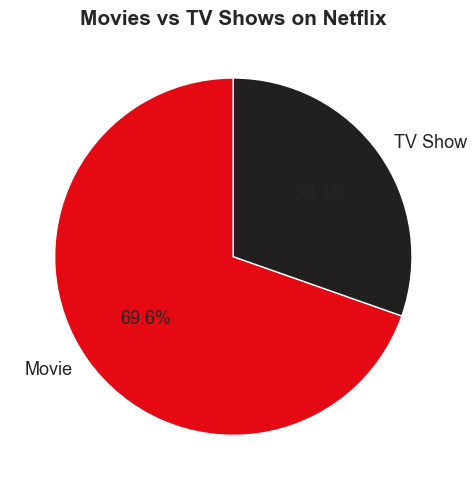

In [6]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221F1F'], startangle=90,
        textprops={'fontsize': 13})
plt.title('Movies vs TV Shows on Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png', dpi=150)
plt.show()

/var/folders/lf/3_jv5tr506q7ldf3r5v74t180000gp/T/ipykernel_2047/1308763498.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


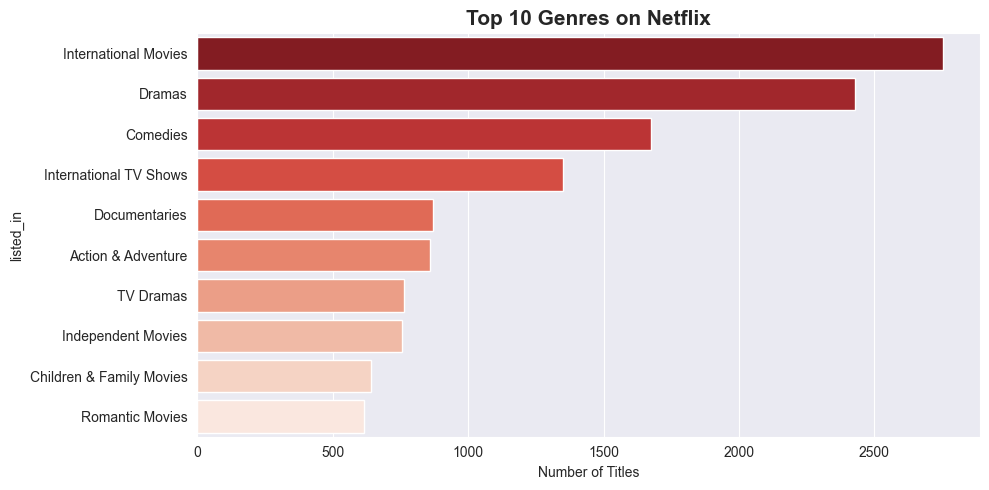

In [7]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150)
plt.show()

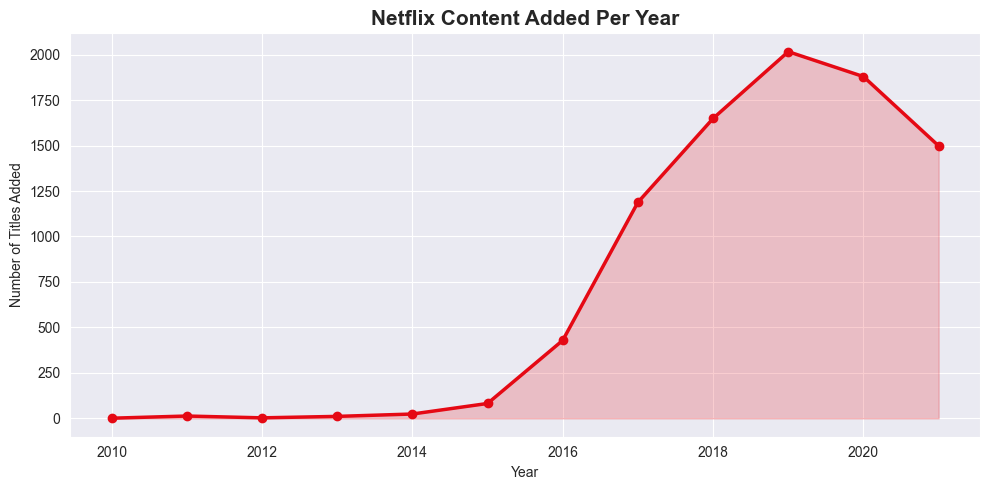

In [8]:
yearly = df['year_added'].value_counts().sort_index()
yearly = yearly[yearly.index >= 2010]

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='#E50914', linewidth=2.5)
plt.fill_between(yearly.index, yearly.values, alpha=0.2, color='#E50914')
plt.title('Netflix Content Added Per Year', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.savefig('content_per_year.png', dpi=150)
plt.show()

/var/folders/lf/3_jv5tr506q7ldf3r5v74t180000gp/T/ipykernel_2047/129824129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='OrRd_r')


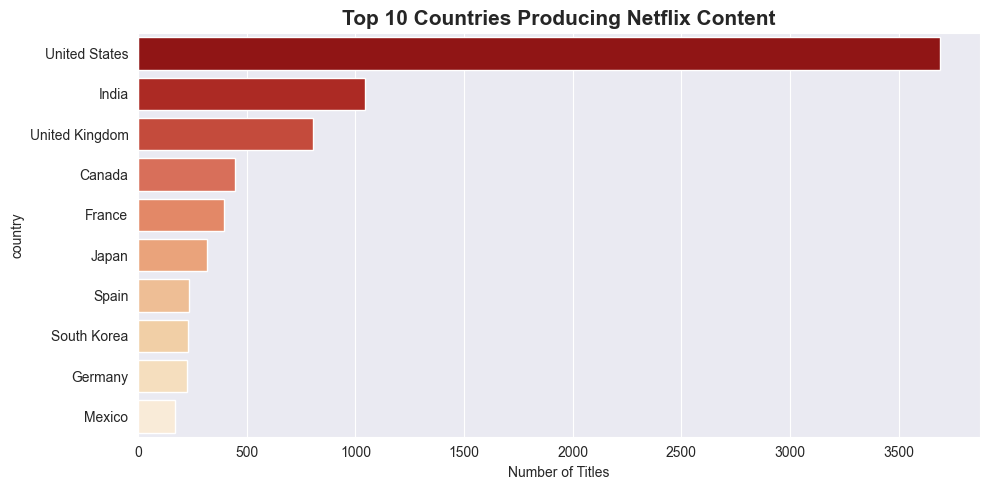

In [9]:
countries = df['country'].str.split(', ').explode()
top_countries = countries[countries != 'Unknown'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='OrRd_r')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

/var/folders/lf/3_jv5tr506q7ldf3r5v74t180000gp/T/ipykernel_2047/3478341585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='Reds_r')


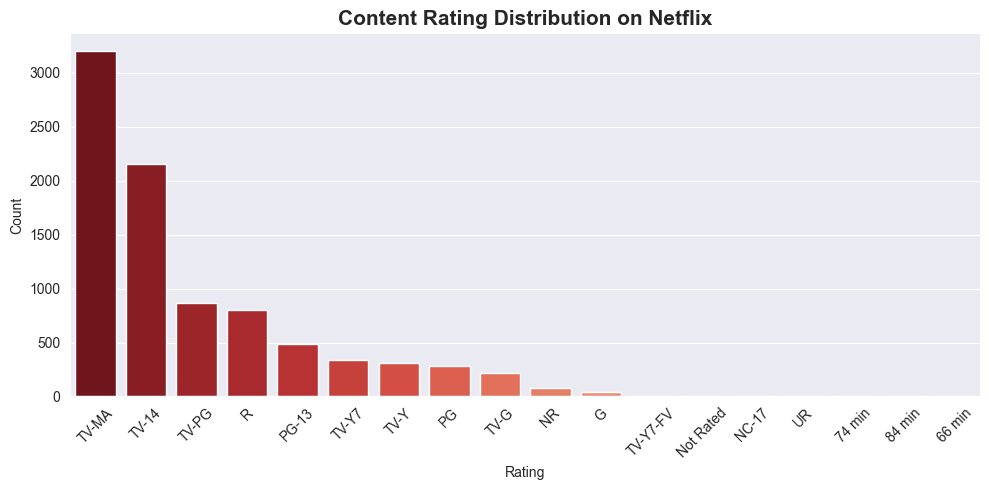

In [10]:
rating_order = df['rating'].value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', order=rating_order, palette='Reds_r')
plt.title('Content Rating Distribution on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

In [11]:
print("=" * 45)
print("       NETFLIX DATA ANALYSIS SUMMARY")
print("=" * 45)
print(f"Total Titles          : {len(df)}")
print(f"Total Movies          : {len(df[df['type']=='Movie'])}")
print(f"Total TV Shows        : {len(df[df['type']=='TV Show'])}")
print(f"Year Range            : {int(df['year_added'].min())} - {int(df['year_added'].max())}")
print(f"Top Genre             : {genres.value_counts().index[0]}")
print(f"Top Country           : {countries.value_counts().index[0]}")
print(f"Most Common Rating    : {df['rating'].value_counts().index[0]}")
print("=" * 45)

       NETFLIX DATA ANALYSIS SUMMARY
Total Titles          : 8807
Total Movies          : 6131
Total TV Shows        : 2676
Year Range            : 2008 - 2021
Top Genre             : International Movies
Top Country           : United States
Most Common Rating    : TV-MA
